In [1]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher as dc
import decipher_vz as dc_vz
import decipher_vz2 as dc_vz2
import decipher_mf as dc_mf
dc.pl.activate_journal_quality()
dc_vz.pl.activate_journal_quality()
dc_vz2.pl.activate_journal_quality()
dc_mf.pl.activate_journal_quality()

import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples


# Rho for run

In [ ]:
import sys
sys.path.insert(0, "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Data Generation")
from make_simulated_adata import sweep_shift_sigma, shift_magnitudes_simple_from_normal

In [ ]:
def my_rho_for_run(adata, sigma, model, decipher_seed):
    from scipy.stats import spearmanr
    if model == "decipher_vz":
        import decipher_vz as dc_vz
        from decipher_vz.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'decipher_vz'
    elif model == "decipher_vz2":
        import decipher_vz2 as dc_vz2
        from decipher_vz2.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'decipher_vz2'
    elif model == "decipher_mf":
        import decipher_mf as dc_mf
        from decipher_mf.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'decipher_vz2'
    elif model == "vanilla":
        import decipher as dc
        from decipher.tools._decipher import DecipherConfig as DecipherConfig
        model_tag = 'vanilla'

    config = DecipherConfig(learning_rate=1e-3, seed=decipher_seed)
    dc.tl.decipher_train(adata, config, plot_kwargs={"color": "batch", "title": f"sigma={sigma}"})
    
    #Compute ground truths and manually plot trajectories
    dc.tl.cell_clusters(adata, leiden_resolution = 0.05, n_neighbors= 25, seed = 341)
    filtered = adata.obs["decipher_clusters"].value_counts()>10
    filtered_ids = set(filtered[filtered].index)
    ground_truths = adata.obs.groupby('decipher_clusters')['latent_t'].mean().sort_values().index.to_list()
    ground_truths = [c for c in ground_truths if c in filtered_ids]
    dc.tl.trajectories(adata, dc.tl.TConfig('trajectory', cluster_ids_list=ground_truths))
    dc.tl.decipher_rotate_space(adata)

    #Compute decipher time
    dc.tl.decipher_time(adata)
    m = adata.obs["decipher_time"].notna()
    rho, _ = spearmanr(adata.obs["decipher_time"][m], adata.obs["latent_t"][m])

    # Save the TRAINED adata (has decipher_z, decipher_v, decipher_time) so we
    # never need to re-run decipher_train to get inferred z later.
    # trained_dir = os.path.join(os.path.dirname(gt_h5ad_path), "trained", model_tag)
    # os.makedirs(trained_dir, exist_ok=True)
    # trained_h5ad_path = os.path.join(
    #     trained_dir, f"sigma{sigma}_seed{seed}_{model_tag}.h5ad"
    # )
    # adata.write(trained_h5ad_path)

    return abs(rho), adata 

Epoch 239 (batch 22/22) | | train elbo: 79.64 (last epoch: 79.82) | val ll: 89.07:  24%|██▍       | 239/1000 [03:22<10:44,  1.18it/s]2026-07-17 17:57:59,271 | INFO : Early stopping has been triggered.
2026-07-17 17:57:59,282 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-17 17:57:59,283 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-17 17:57:59,285 | INFO : Saving decipher model with run_id 2026-07-17-17-57-59-uniform-avocado-bagel.


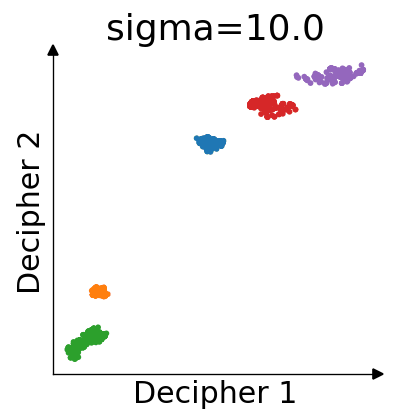

2026-07-17 17:58:00,436 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-07-17 17:58:00,437 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-07-17 17:58:00,501 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 0.05.
2026-07-17 17:58:00,898 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
2026-07-17 17:58:00,903 | INFO : Trajectory trajectory : ['33', '28', '12', '14', '9', '22', '4', '27', '23', '10', '2', '8', '20', '19', '1', '32', '31', '3', '25', '13', '24', '16', '21', '0', '30', '7', '15', '5', '26', '11', '29', '6', '18', '34', '17'])
2026-07-17 17:58:00,957 | INFO : Added trajectory trajectory to `adata.uns['decipher']['trajectories']`.
2026-07-17 17:58:00,970 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-07-17 17:58:00,970 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-07-17 17:58:00,983 | INFO : Added `.obs['decipher_time']`: the decipher

   sigma  decipher_vz  decipher_vz2  native decipher
0    0.1     0.942453      0.942080         0.936318
1    0.5     0.924917      0.941581         0.934135
2    1.0     0.914642      0.924127         0.915815
3    2.5     0.885797      0.681948         0.910892
4    5.0     0.520951      0.340396         0.636303
5    7.5     0.480489      0.257403         0.706543
6   10.0     0.423950      0.463308         0.661398


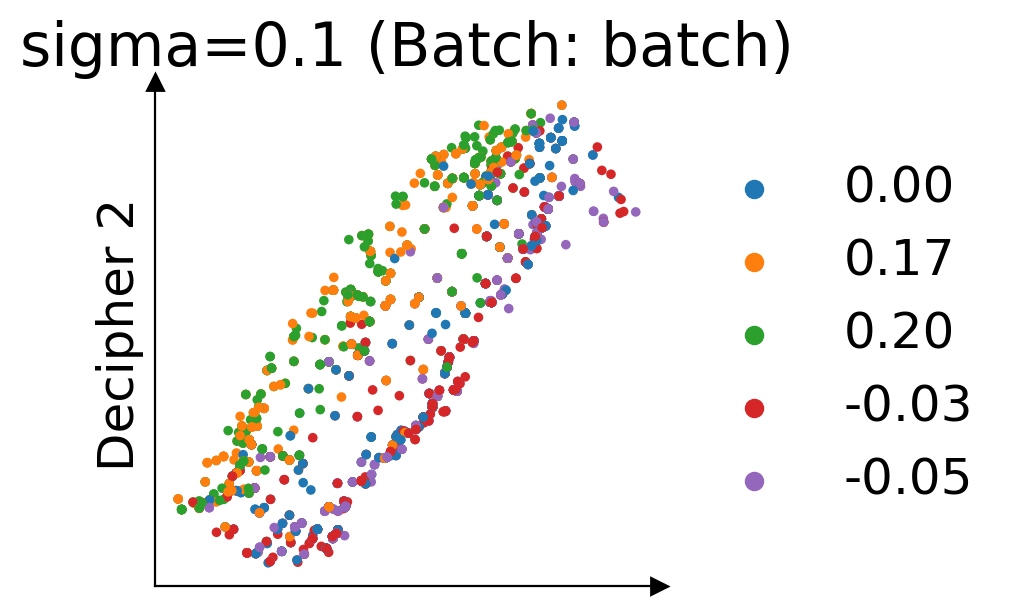

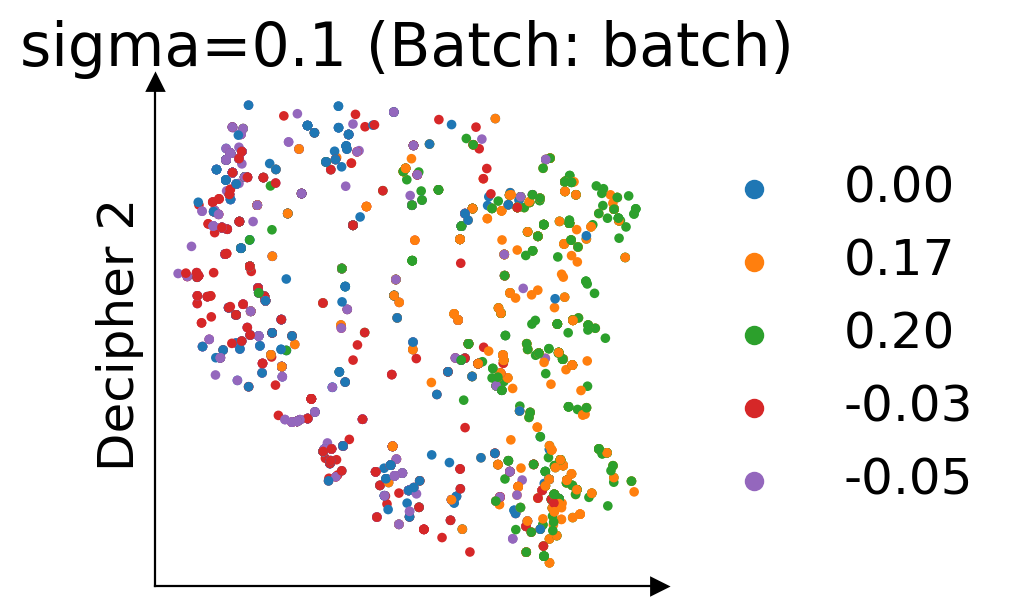

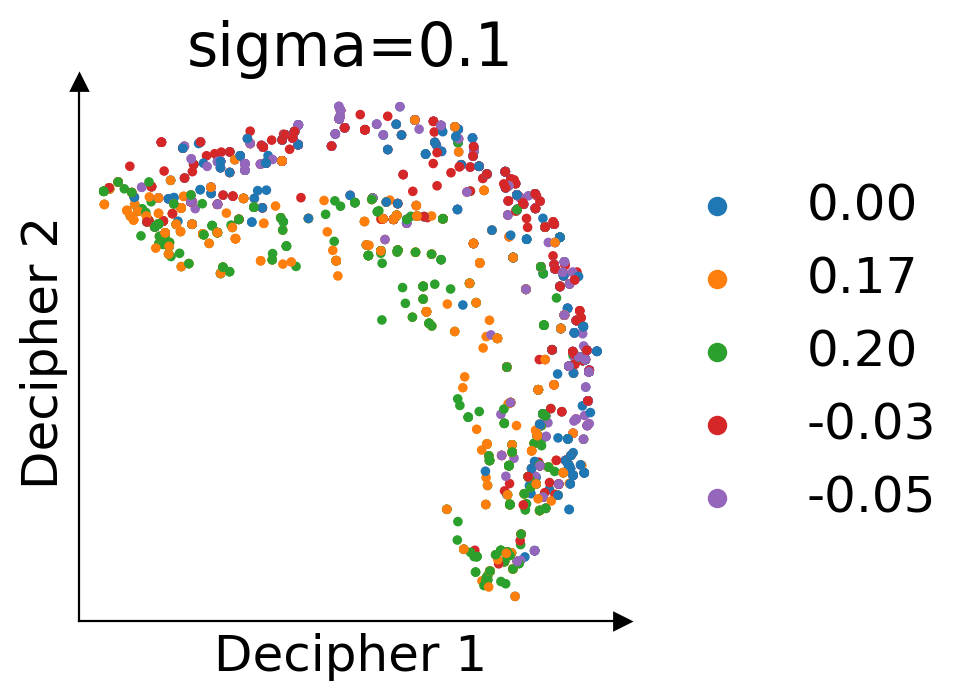

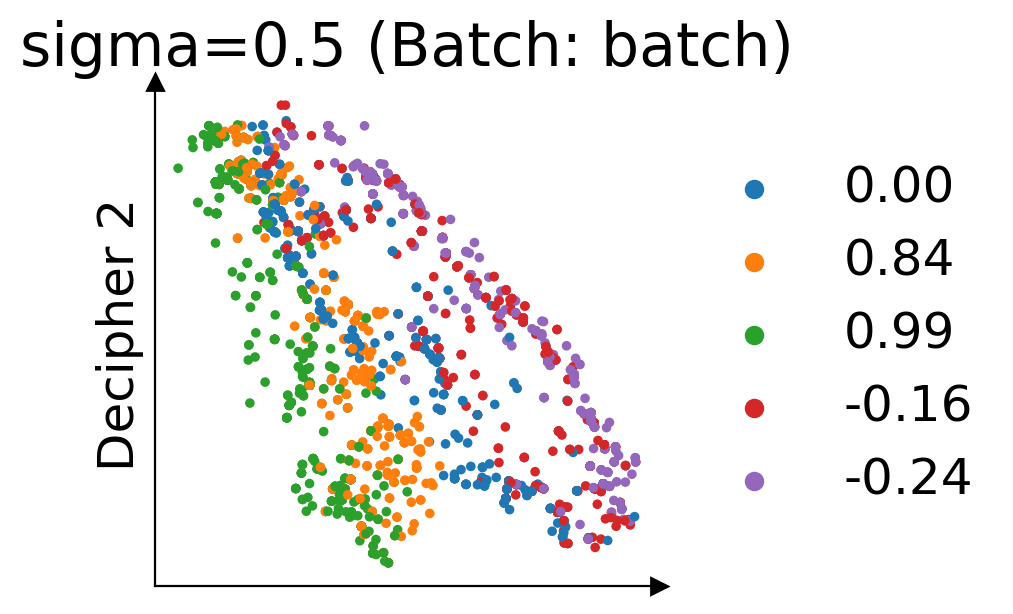

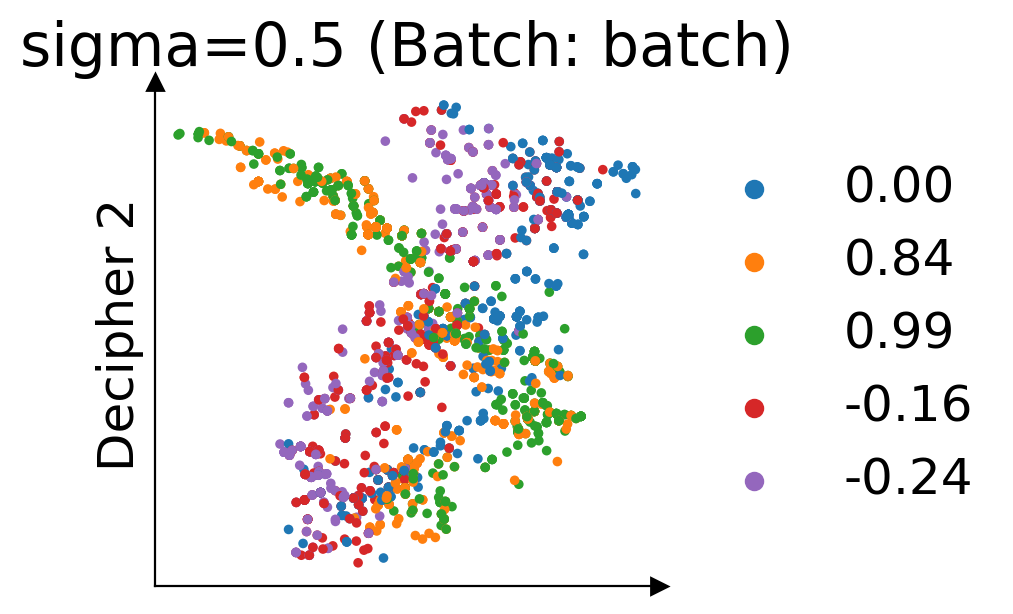

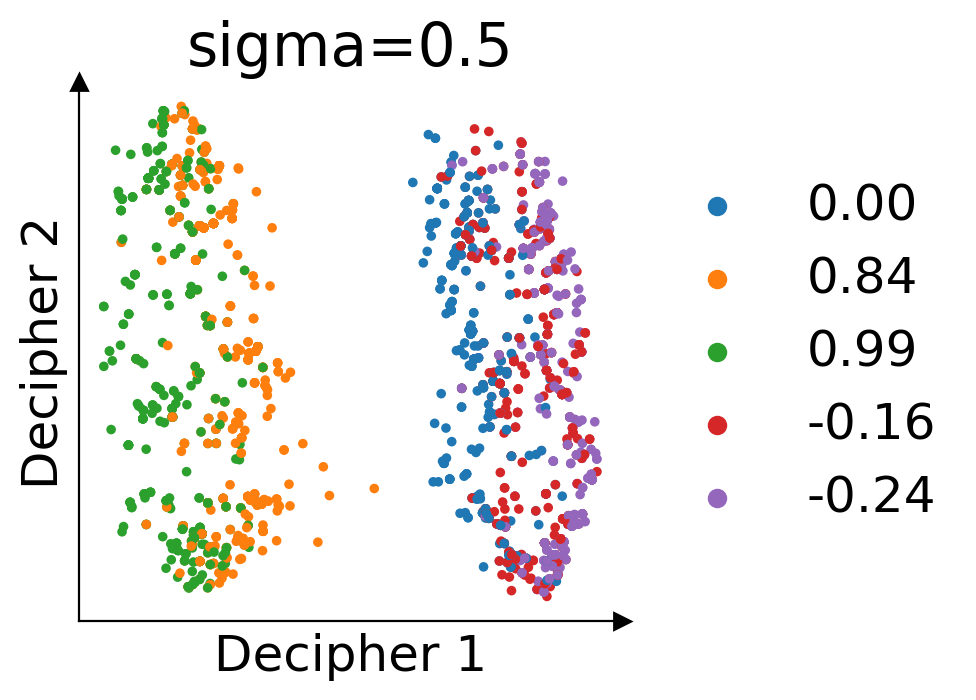

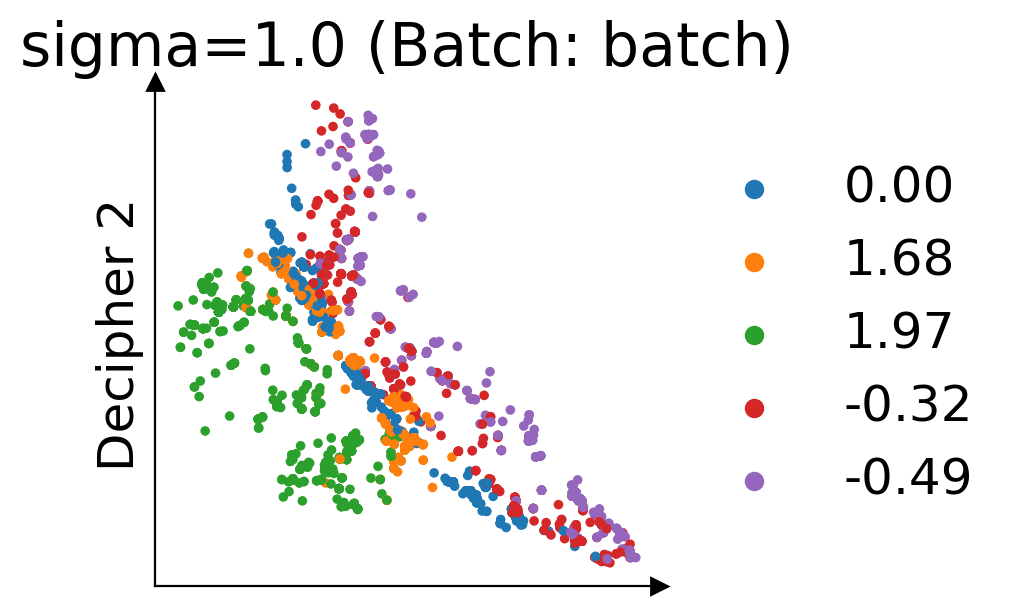

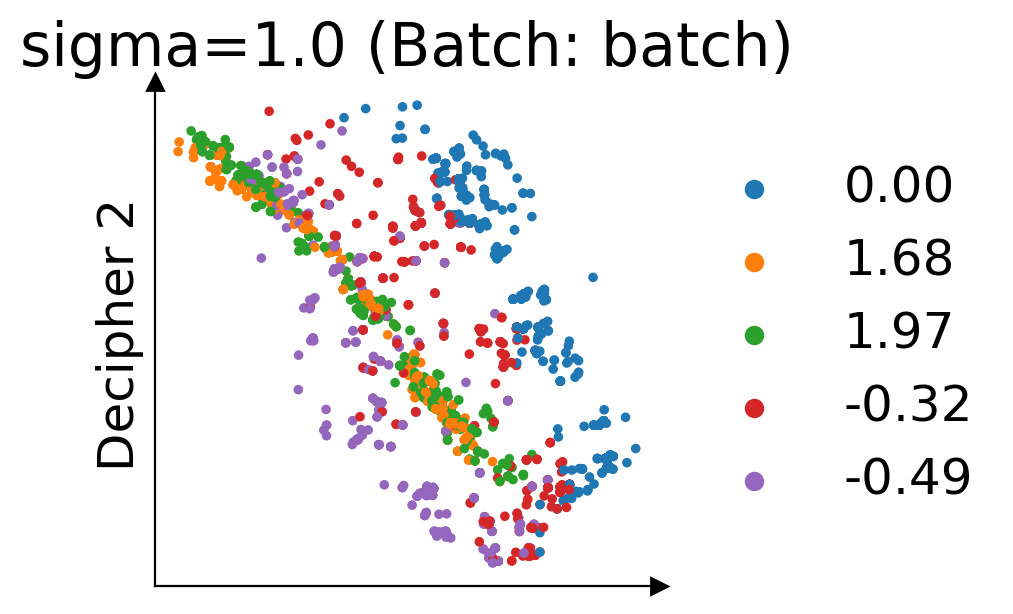

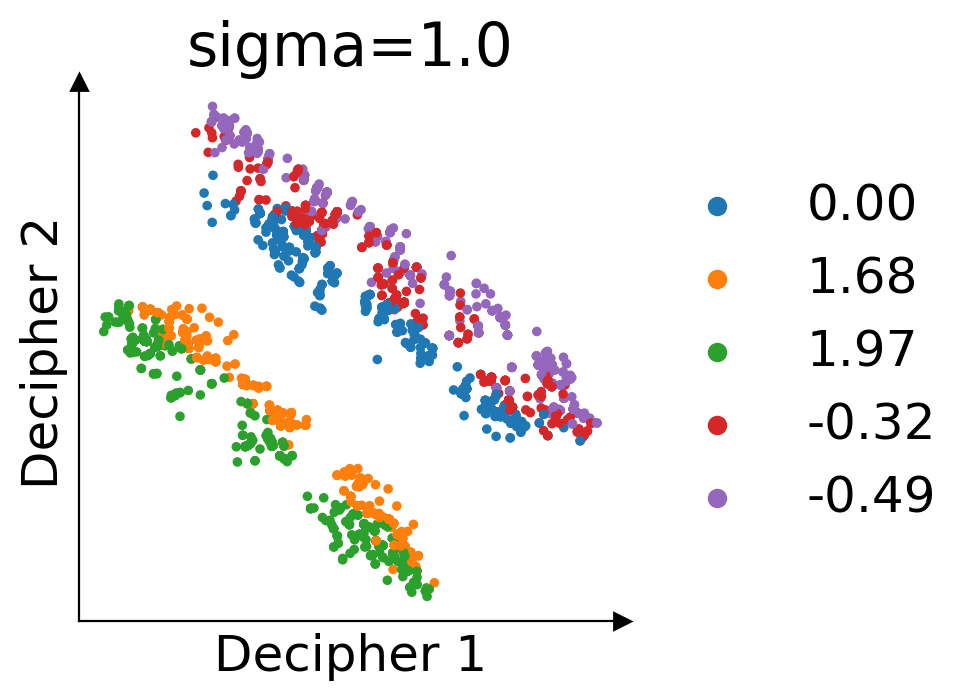

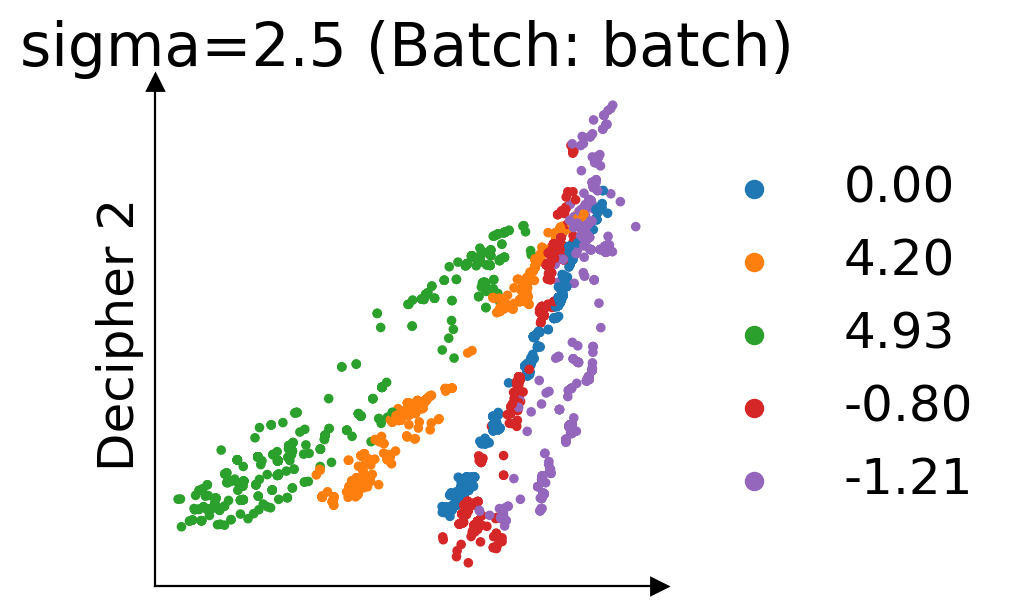

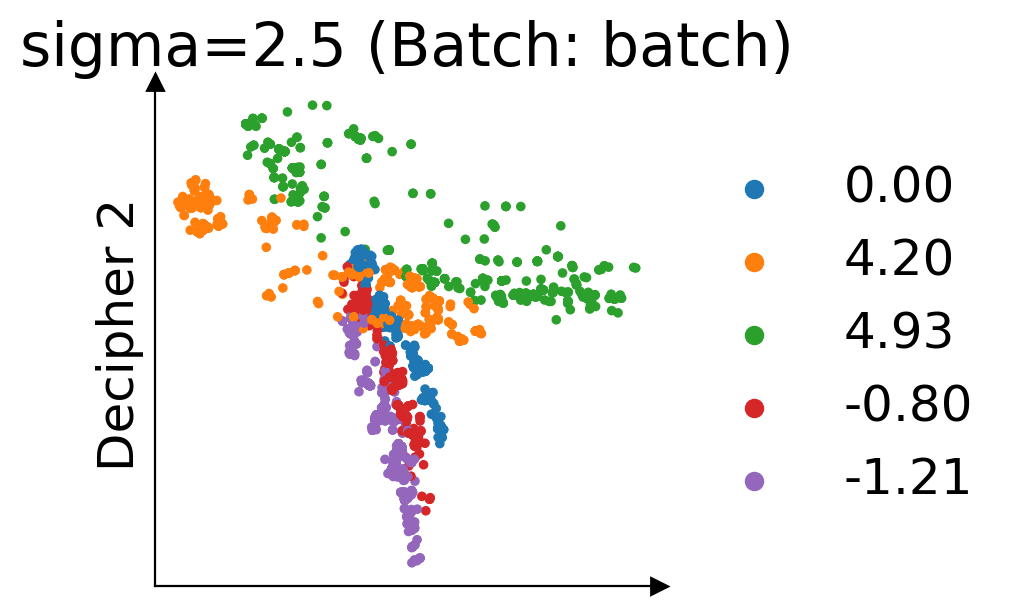

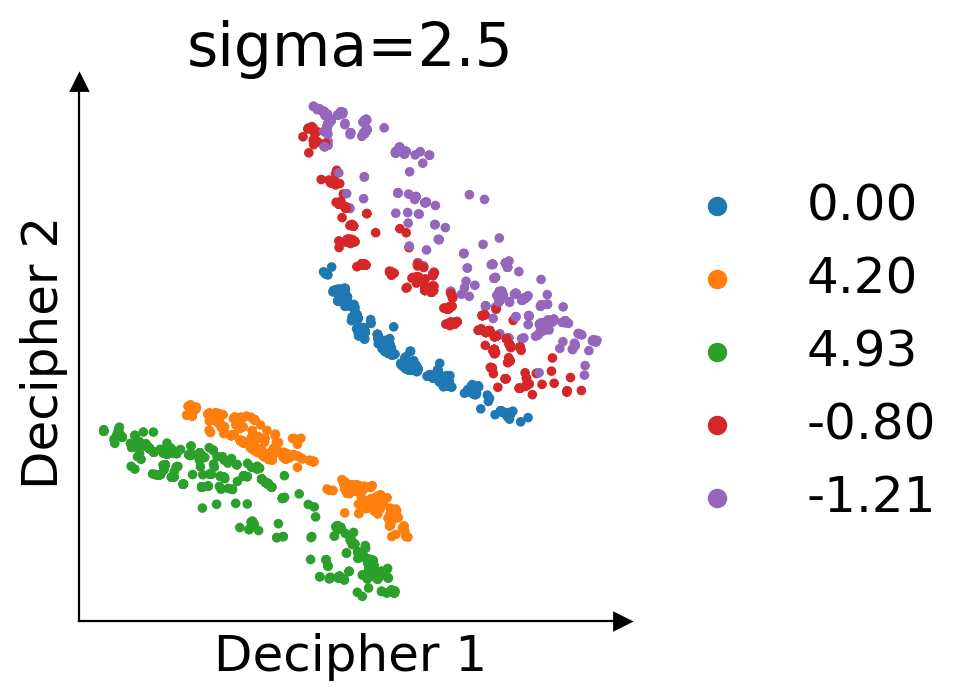

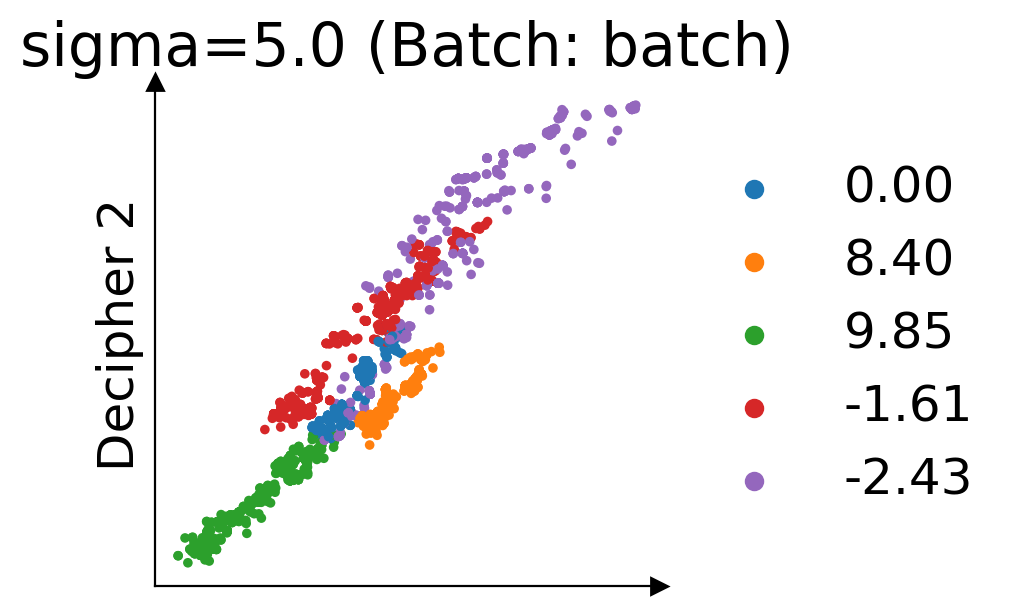

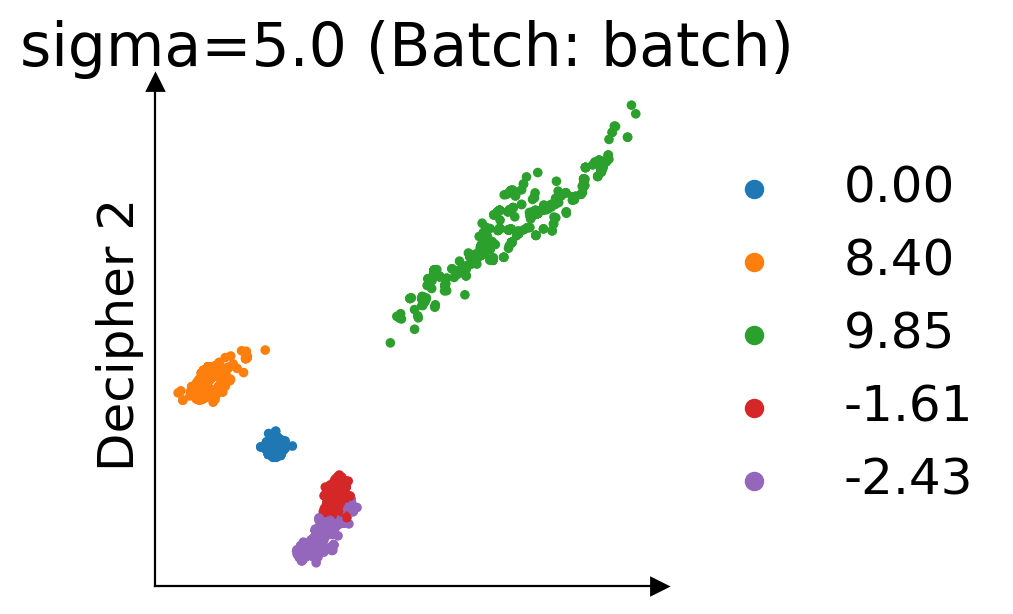

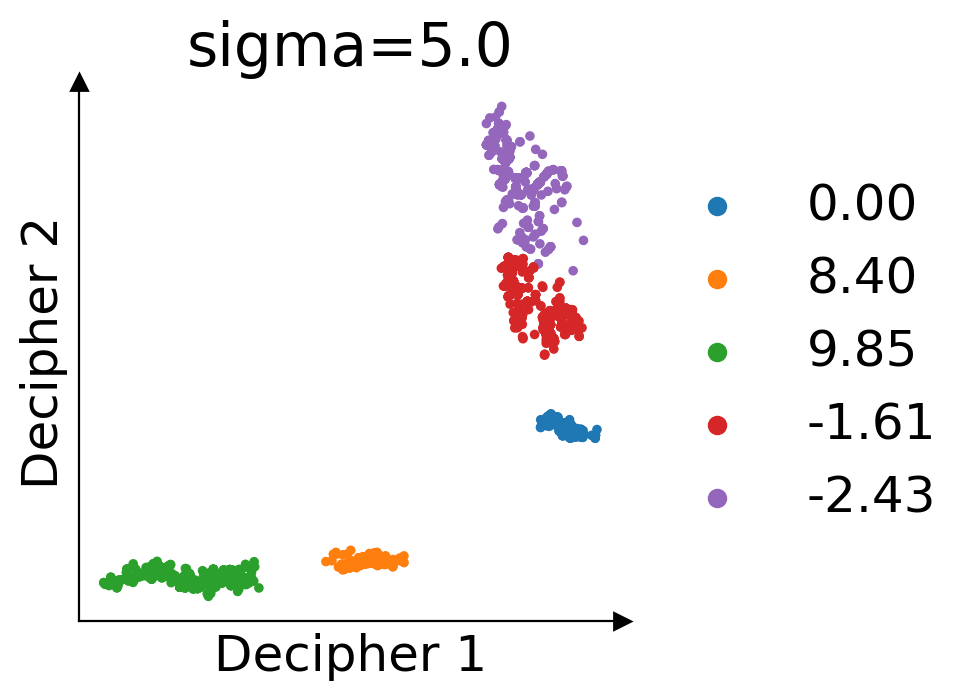

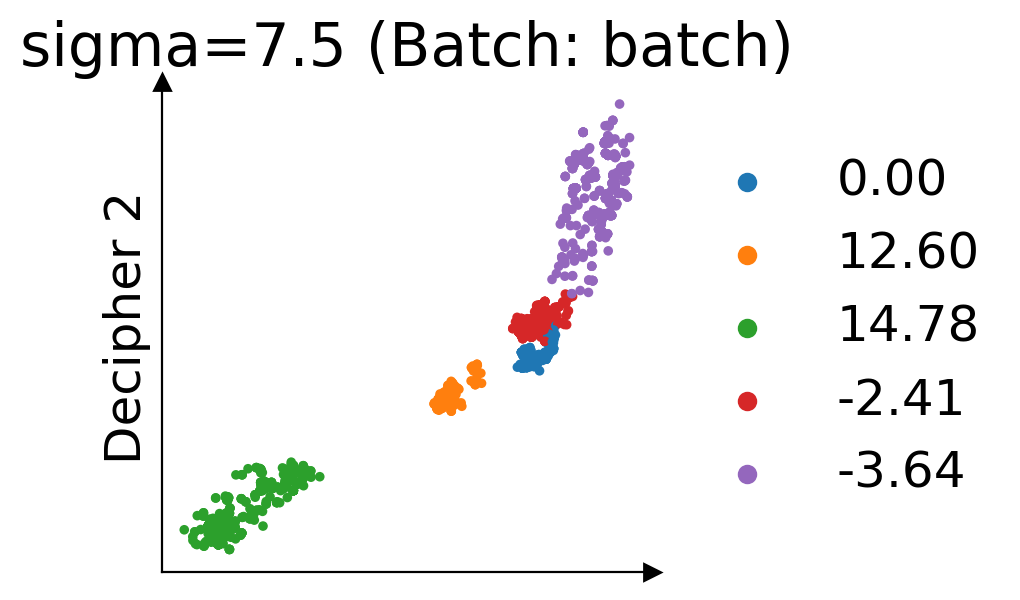

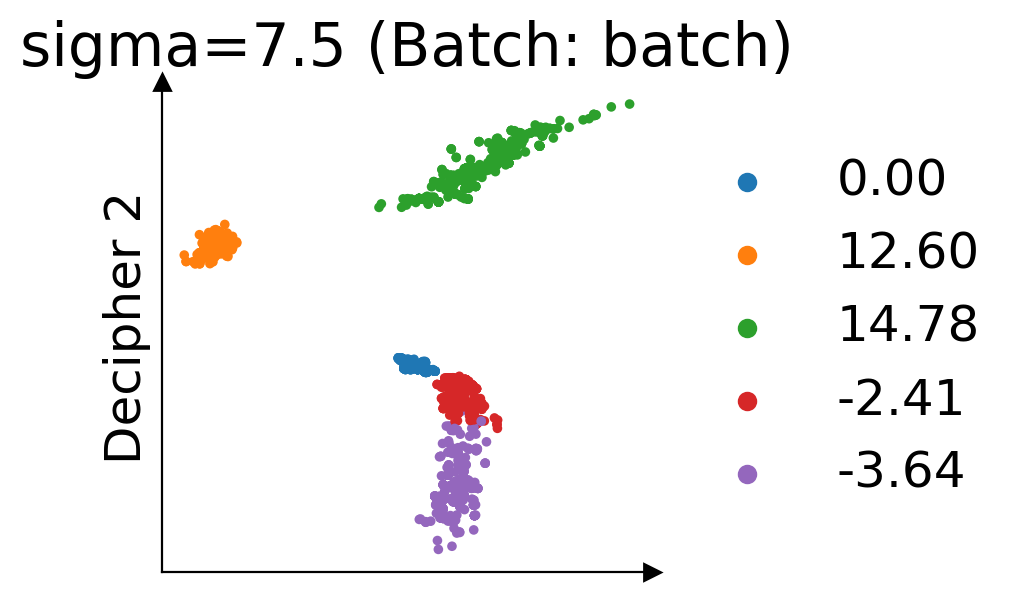

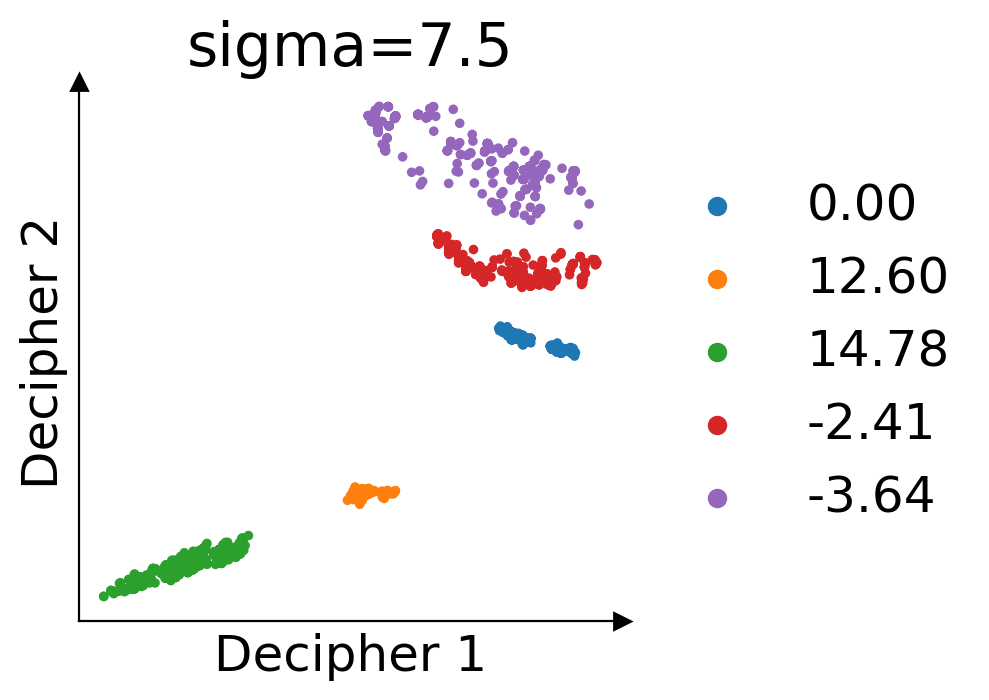

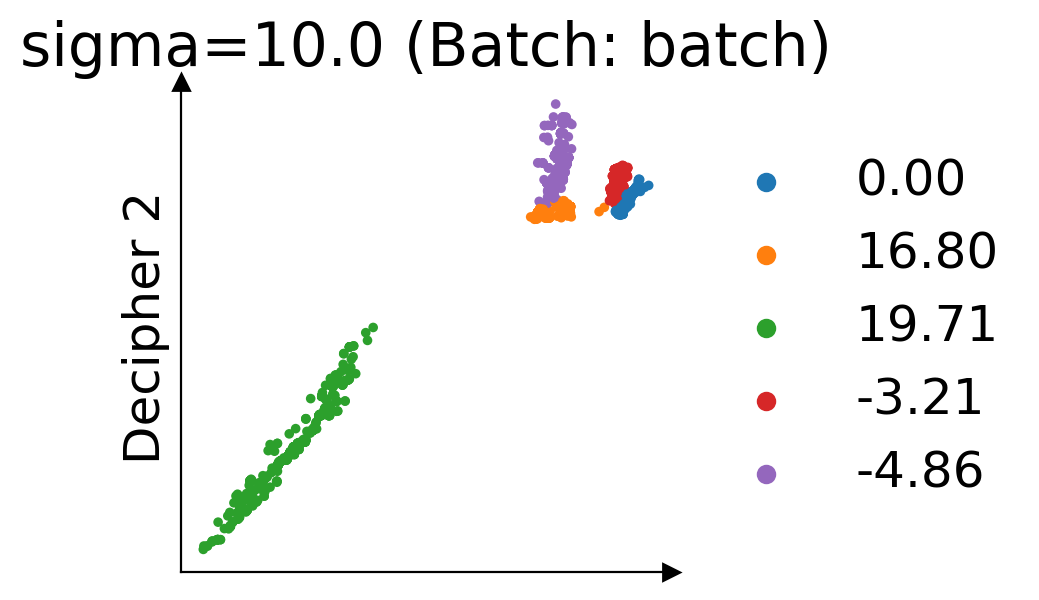

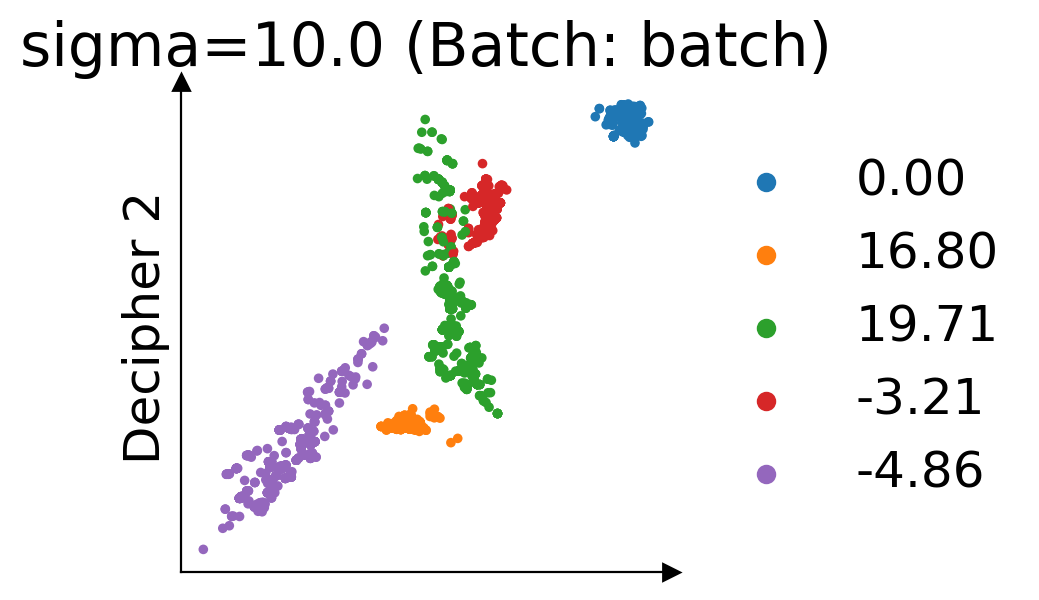

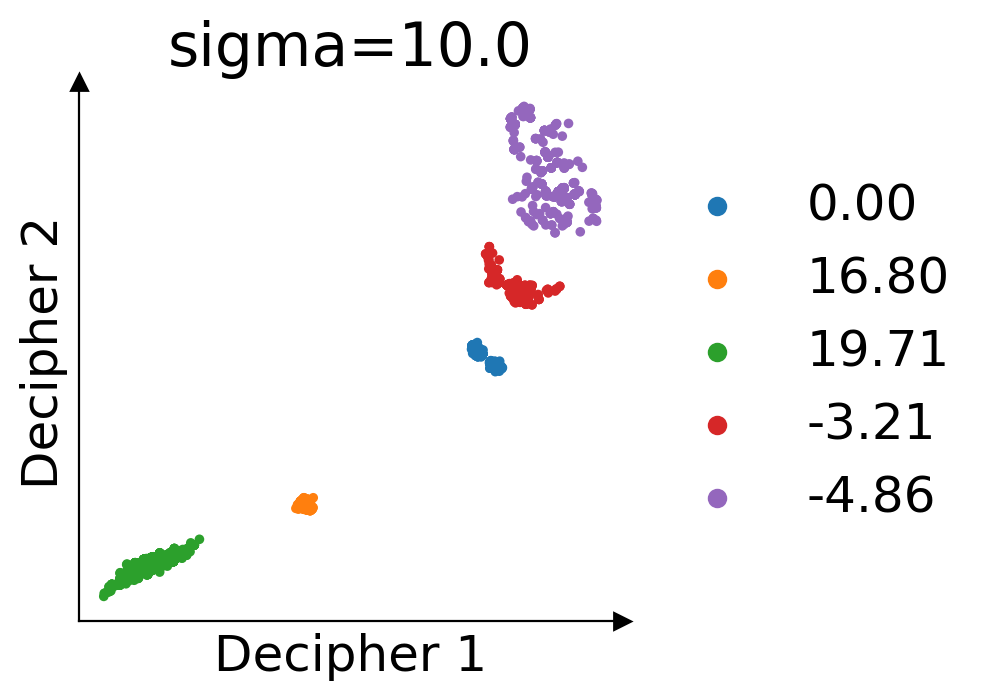

In [ ]:
shift_sigma = [0.1, 0.5, 1.0 ,2.5, 5.0, 7.5, 10.0]
decipher_seeds = [1,2,3]
rhos_list = []

for decipher_seed in decipher_seeds:
    for i, ss in enumerate(shift_sigma):
        current_step = i+1
        adata = shift_magnitudes_simple_from_normal(shift_type="vz", 
                                                    n_batches=5,
                                                    shift_sigma=float(ss),
                                                    n_samples=500, n_genes=50,
                                                    biological_sigma=0.1, seed=0,)
        adata_vz = adata.copy()
        adata_vz.uns["color_palette"] = None
        adata_vz2 = adata.copy()
        adata_vz2.uns["color_palette"] = None
        adata_mf = adata.copy()
        adata_mf.uns["color_palette"] = None
        adata_vanilla = adata.copy()
        adata_vanilla.uns["color_palette"] = None
        color_palette = None
        rho1, trained_adata1 = my_rho_for_run(adata_vz, ss, "decipher_vz", decipher_seed=decipher_seed)
        rho2, trained_adata2 = my_rho_for_run(adata_vz2, ss, "decipher_vz2", decipher_seed=decipher_seed)
        rho3, trained_adata3 = my_rho_for_run(adata_mf, ss, "decipher_mf", decipher_seed=decipher_seed)
        rho4, trained_adata4 = my_rho_for_run(adata_vanilla, ss, "vanilla", decipher_seed=decipher_seed)
        rhos_list.append([ss, rho1, rho2, rho3, rho4])
        

df = pd.DataFrame(rhos_list, columns=['sigma', 'decipher_vz', 'decipher_vz2', 'decipher_mf','vanilla decipher'])
print(df)

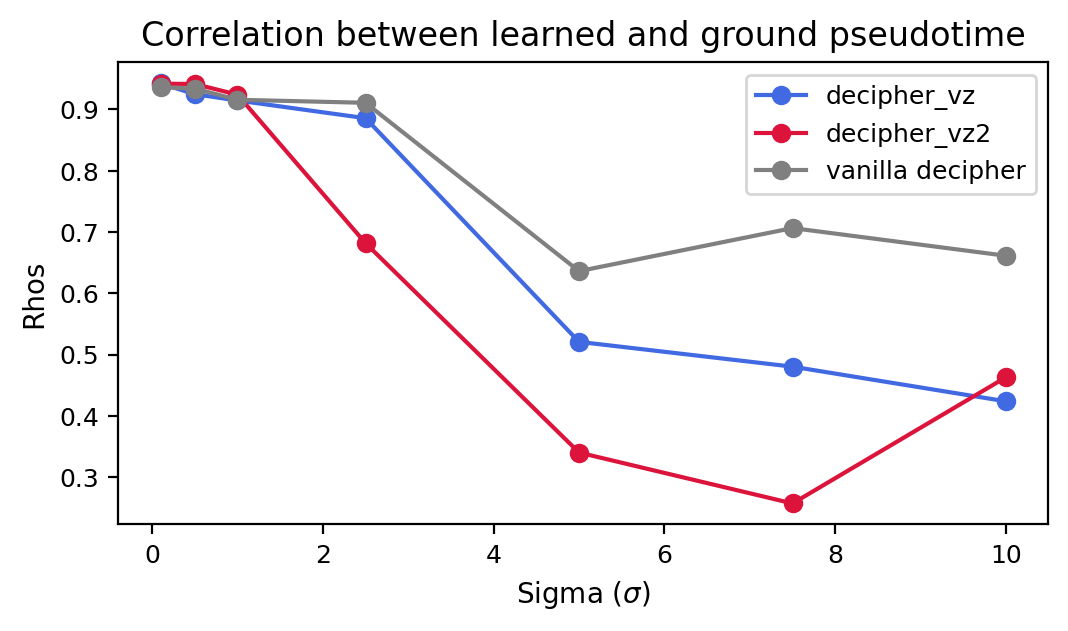

In [ ]:
import matplotlib.pyplot as plt
# 1. Set the figure size FIRST (Width, Height in inches)
plt.figure(figsize=(6, 3))
# Plotting each line against the 'sigma' column
plt.plot(df['sigma'], df['decipher_vz'], label='decipher_vz', color='royalblue', marker='o')
plt.plot(df['sigma'], df['decipher_vz2'], label='decipher_vz2', color='crimson', marker='o')
plt.plot(df['sigma'], df['decipher_mf'], label='decipher_mf', color='green', marker='o')
plt.plot(df['sigma'], df['vanilla decipher'], label='vanilla decipher', color='gray', marker='o')

# Adding labels and styling
plt.xlabel('Sigma ($\sigma$)', fontsize=10)
plt.ylabel('Rhos', fontsize=10)
plt.title('Correlation between learned and ground pseudotime', fontsize=12)
plt.tick_params(axis='both', labelsize=9) 

plt.legend(fontsize=9)
plt.show()